In [42]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pipeline.shared.meteo_feature_mapping import MODEL_FEATURE_COLUMNS

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#0B6E4F', '#F4A261', '#2878B5', '#D1495B', '#7A5195']

DATA_PATH = Path(r'C:\Users\tranq\Downloads\weather_merged_2021_2026_labeled.csv')
TARGET_COLUMNS = ['y_mua_lon', 'y_sat_lo', 'y_dong_loc', 'y_mua_da', 'y_lu_lut']
KEY_COLUMNS = ['location_id', 'time']
assert DATA_PATH.exists(), f'Không tìm thấy dữ liệu: {DATA_PATH}'
print(f'Data: {DATA_PATH} ({DATA_PATH.stat().st_size / 1024**2:,.1f} MiB)')

Data: C:\Users\tranq\Downloads\weather_merged_2021_2026_labeled.csv (220.2 MiB)


## 1. Nạp dữ liệu với kiểu dữ liệu tiết kiệm bộ nhớ

Các biến thời tiết dùng `float32`, nhãn dùng `int8`, `location_id` dùng `int16`; `time` được parse thành `datetime64`. Cách này giảm đáng kể RAM so với suy luận kiểu mặc định.

In [43]:
header = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
source_feature_columns = [c for c in header if c not in KEY_COLUMNS + TARGET_COLUMNS]
missing_model_features = set(MODEL_FEATURE_COLUMNS).difference(source_feature_columns)
assert not missing_model_features, f'Dữ liệu train thiếu feature: {sorted(missing_model_features)}'
feature_columns = MODEL_FEATURE_COLUMNS
dtype_map = {c: 'float32' for c in feature_columns}
dtype_map.update({'location_id': 'int16', **{c: 'int8' for c in TARGET_COLUMNS}})

df = pd.read_csv(DATA_PATH, dtype=dtype_map, parse_dates=['time'])
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns; RAM: {memory_mb:,.1f} MiB')
display(df.head())

Shape: 2,184,840 rows × 22 columns; RAM: 156.3 MiB


,location_id,time,temperature_2m (°C),dew_point_2m (°C),precipitation (mm),surface_pressure (hPa),wind_speed_10m (km/h),cloud_cover (%),rain (mm),snow_depth (m),snowfall (cm),wind_gusts_10m (km/h),et0_fao_evapotranspiration (mm),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),y_mua_lon,y_sat_lo,y_dong_loc,y_mua_da,y_lu_lut
0,0,2021-01-01,8.4000,5.5000,0.0000,937.5000,5.5000,89.0000,0.0000,0.0000,0.0000,11.5000,0.0200,12.2000,13.8000,0.3470,0.3540,0,0,0,0,0
1,1,2021-01-01,8.8000,5.5000,0.0000,937.1000,6.3000,93.0000,0.0000,0.0000,0.0000,16.2000,0.0200,12.7000,14.2000,0.3780,0.3740,0,0,0,0,0
2,2,2021-01-01,8.9000,6.6000,0.0000,964.6000,6.0000,85.0000,0.0000,0.0000,0.0000,21.6000,0.0000,14.8000,15.9000,0.3170,0.3300,0,0,0,0,0
3,3,2021-01-01,5.6000,4.0000,0.0000,902.0000,5.5000,79.0000,0.0000,0.0000,0.0000,20.5000,0.0000,10.2000,12.6000,0.3890,0.4020,0,0,0,0,0
4,4,2021-01-01,7.4000,4.1000,0.0000,919.6000,3.8000,74.0000,0.0000,0.0000,0.0000,12.2000,0.0000,11.1000,13.1000,0.3310,0.3410,0,0,0,0,0


In [44]:
schema = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': df.isna().mean().mul(100),
    'n_unique': df.nunique(dropna=False),
})
display(schema)
assert list(df.columns[-5:]) == TARGET_COLUMNS, '5 cột cuối không khớp danh sách nhãn dự kiến.'

,dtype,missing,missing_pct,n_unique
location_id,int16,0,0.0000,42
time,datetime64[ns],0,0.0000,48552
temperature_2m (°C),float32,0,0.0000,420
dew_point_2m (°C),float32,0,0.0000,356
precipitation (mm),float32,0,0.0000,256
surface_pressure (hPa),float32,0,0.0000,1696
wind_speed_10m (km/h),float32,0,0.0000,251
cloud_cover (%),float32,0,0.0000,101
rain (mm),float32,0,0.0000,256
snow_depth (m),float32,0,0.0000,1


In [45]:
df.dtypes

location_id                                 int16
time                               datetime64[ns]
temperature_2m (°C)                       float32
dew_point_2m (°C)                         float32
precipitation (mm)                        float32
surface_pressure (hPa)                    float32
wind_speed_10m (km/h)                     float32
cloud_cover (%)                           float32
rain (mm)                                 float32
snow_depth (m)                            float32
snowfall (cm)                             float32
wind_gusts_10m (km/h)                     float32
et0_fao_evapotranspiration (mm)           float32
soil_temperature_0_to_7cm (°C)            float32
soil_temperature_7_to_28cm (°C)           float32
soil_moisture_0_to_7cm (m³/m³)            float32
soil_moisture_7_to_28cm (m³/m³)           float32
y_mua_lon                                    int8
y_sat_lo                                     int8
y_dong_loc                                   int8


In [46]:
df_sample = df.sample(100, random_state=42)
df_sample.to_csv("df_sample.csv")

## 2. Phạm vi và tính liên tục

Kiểm tra khoảng thời gian, số mốc giờ, số địa điểm và số dòng trên mỗi mốc giờ.

In [47]:
coverage = pd.Series({
    'rows': len(df),
    'columns': df.shape[1],
    'time_min': df['time'].min(),
    'time_max': df['time'].max(),
    'unique_hours': df['time'].nunique(),
    'unique_location_ids': df['location_id'].nunique(),
    'rows_per_hour_min': df.groupby('time').size().min(),
    'rows_per_hour_max': df.groupby('time').size().max(),
})
display(coverage.to_frame('value'))

expected_hours = pd.date_range(df['time'].min(), df['time'].max(), freq='h')
missing_hours = expected_hours.difference(pd.DatetimeIndex(df['time'].unique()))
print(f'Số giờ thiếu trên trục thời gian chung: {len(missing_hours):,}')
print('location_id thiếu trong khoảng min–max:', sorted(set(range(df.location_id.min(), df.location_id.max() + 1)) - set(df.location_id.unique())))

,value
rows,2184840
columns,22
time_min,2021-01-01 00:00:00
time_max,2026-07-16 23:00:00
unique_hours,48552
unique_location_ids,42
rows_per_hour_min,45
rows_per_hour_max,45


Số giờ thiếu trên trục thời gian chung: 0
location_id thiếu trong khoảng min–max: [15, 27]


## 3. Kiểm định nhiều quan sát trên `(location_id, time)`

Một `location_id` mới có thể bao gồm nhiều đơn vị hành chính cũ với địa hình khác nhau. Vì vậy nhiều dòng tại cùng `(location_id, time)` là chủ đích thu thập, không phải nhiễu. Theo quyết định của team, các biến thời tiết được lấy trung bình cộng; mỗi nhãn `y_*` bằng 1 nếu trung bình nhãn trong nhóm khác 0.

In [48]:
key_size = df.groupby(KEY_COLUMNS, observed=True).size()
duplicate_key_count = int(key_size.gt(1).sum())
duplicate_extra_rows = int(key_size.sub(1).clip(lower=0).sum())
duplicate_rows = df[df.duplicated(KEY_COLUMNS, keep=False)].sort_values(KEY_COLUMNS)

location_counts = df.groupby('location_id').size().rename('rows')
normal_rows = df['time'].nunique()
display(location_counts[location_counts.ne(normal_rows)].to_frame())
print(f'Khóa bị trùng: {duplicate_key_count:,}; số dòng dư: {duplicate_extra_rows:,}')
display(duplicate_rows.head(8))

,rows
location_id,
17,97104
25,97104
31,97104


Khóa bị trùng: 145,656; số dòng dư: 145,656


,location_id,time,temperature_2m (°C),dew_point_2m (°C),precipitation (mm),surface_pressure (hPa),wind_speed_10m (km/h),cloud_cover (%),rain (mm),snow_depth (m),snowfall (cm),wind_gusts_10m (km/h),et0_fao_evapotranspiration (mm),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),y_mua_lon,y_sat_lo,y_dong_loc,y_mua_da,y_lu_lut
16,17,2021-01-01 00:00:00,2.7000,0.8000,0.0000,879.6000,4.0000,28.0000,0.0000,0.0000,0.0000,18.4000,0.0000,8.2000,12.1000,0.1660,0.2720,0,0,0,0,0
17,17,2021-01-01 00:00:00,4.7000,2.8000,0.0000,908.1000,4.0000,28.0000,0.0000,0.0000,0.0000,18.4000,0.0000,10.2000,14.0000,0.1660,0.2720,0,0,0,0,0
61,17,2021-01-01 01:00:00,4.5000,-0.1000,0.0000,880.9000,5.4000,77.0000,0.0000,0.0000,0.0000,22.3000,0.0400,8.2000,12.0000,0.1660,0.2720,0,0,0,0,0
62,17,2021-01-01 01:00:00,6.4000,1.8000,0.0000,909.3000,5.4000,77.0000,0.0000,0.0000,0.0000,22.3000,0.0400,10.1000,13.9000,0.1660,0.2720,0,0,0,0,0
106,17,2021-01-01 02:00:00,6.4000,-0.2000,0.0000,881.7000,6.6000,35.0000,0.0000,0.0000,0.0000,26.3000,0.1200,9.0000,11.9000,0.1660,0.2720,0,0,0,0,0
107,17,2021-01-01 02:00:00,8.3000,1.8000,0.0000,910.0000,6.6000,35.0000,0.0000,0.0000,0.0000,26.3000,0.1300,10.9000,13.8000,0.1660,0.2720,0,0,0,0,0
151,17,2021-01-01 03:00:00,8.4000,-0.4000,0.0000,882.3000,7.4000,75.0000,0.0000,0.0000,0.0000,27.7000,0.2200,10.4000,11.8000,0.1660,0.2720,0,0,0,0,0
152,17,2021-01-01 03:00:00,10.3000,1.6000,0.0000,910.4000,7.4000,75.0000,0.0000,0.0000,0.0000,27.7000,0.2300,12.4000,13.8000,0.1660,0.2720,0,0,0,0,0


In [49]:
df['y_lu_lut'].unique()

array([0, 1], dtype=int8)

In [50]:
duplicate_conflicts = pd.Series({
    c: duplicate_rows.groupby(KEY_COLUMNS, observed=True)[c].nunique().gt(1).sum()
    for c in feature_columns + TARGET_COLUMNS
}, name='duplicate_keys_with_conflicting_values').sort_values(ascending=False)
display(duplicate_conflicts.to_frame())

,duplicate_keys_with_conflicting_values
temperature_2m (°C),145656
dew_point_2m (°C),145656
surface_pressure (hPa),145656
soil_temperature_0_to_7cm (°C),145656
soil_temperature_7_to_28cm (°C),145656
et0_fao_evapotranspiration (mm),40545
precipitation (mm),0
wind_speed_10m (km/h),0
snow_depth (m),0
rain (mm),0


## 3.1. Chuẩn hóa về một dòng cho mỗi đơn vị hành chính mới mỗi giờ

Các feature thời tiết được lấy trung bình cộng. Với nhãn nhị phân, quy tắc `(mean != 0)` tương đương phép OR: chỉ cần một quan sát thành phần có nhãn dương thì nhãn của đơn vị mới bằng 1.

In [51]:
group_columns = ['location_id', 'time']

weather_mean = (
    df.groupby(group_columns, as_index=False, observed=True)[feature_columns]
      .mean()
)

target_mean = (
    df.groupby(group_columns, as_index=False, observed=True)[TARGET_COLUMNS]
      .mean()
)
target_mean[TARGET_COLUMNS] = target_mean[TARGET_COLUMNS].ne(0).astype('int8')

df_model = weather_mean.merge(
    target_mean,
    on=group_columns,
    how='inner',
    validate='one_to_one',
)

assert not df_model.duplicated(group_columns).any()
assert set(df_model[TARGET_COLUMNS].stack().unique()).issubset({0, 1})
print(f'Trước gộp: {len(df):,} dòng')
print(f'Sau gộp:   {len(df_model):,} dòng')
display(df_model.head())

Trước gộp: 2,184,840 dòng
Sau gộp:   2,039,184 dòng


,location_id,time,temperature_2m (°C),dew_point_2m (°C),precipitation (mm),surface_pressure (hPa),wind_speed_10m (km/h),cloud_cover (%),rain (mm),snow_depth (m),snowfall (cm),wind_gusts_10m (km/h),et0_fao_evapotranspiration (mm),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),y_mua_lon,y_sat_lo,y_dong_loc,y_mua_da,y_lu_lut
0,0,2021-01-01 00:00:00,8.4000,5.5000,0.0000,937.5000,5.5000,89.0000,0.0000,0.0000,0.0000,11.5000,0.0200,12.2000,13.8000,0.3470,0.3540,0,0,0,0,0
1,0,2021-01-01 01:00:00,9.9000,5.7000,0.0000,938.5000,4.2000,77.0000,0.0000,0.0000,0.0000,15.1000,0.0300,12.0000,13.8000,0.3470,0.3540,0,0,0,0,0
2,0,2021-01-01 02:00:00,11.3000,6.0000,0.0000,939.2000,5.6000,80.0000,0.0000,0.0000,0.0000,20.2000,0.1200,12.2000,13.7000,0.3470,0.3540,0,0,0,0,0
3,0,2021-01-01 03:00:00,13.2000,6.3000,0.0000,939.4000,6.6000,89.0000,0.0000,0.0000,0.0000,23.4000,0.2300,12.8000,13.7000,0.3470,0.3540,0,0,0,0,0
4,0,2021-01-01 04:00:00,14.8000,6.6000,0.0000,938.6000,7.0000,95.0000,0.0000,0.0000,0.0000,25.2000,0.3000,13.5000,13.7000,0.3460,0.3540,0,0,0,0,0


In [52]:
df_model.loc[df_model['location_id'] ==17]

,location_id,time,temperature_2m (°C),dew_point_2m (°C),precipitation (mm),surface_pressure (hPa),wind_speed_10m (km/h),cloud_cover (%),rain (mm),snow_depth (m),snowfall (cm),wind_gusts_10m (km/h),et0_fao_evapotranspiration (mm),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),y_mua_lon,y_sat_lo,y_dong_loc,y_mua_da,y_lu_lut
776832,17,2021-01-01 00:00:00,3.7000,1.8000,0.0000,893.8500,4.0000,28.0000,0.0000,0.0000,0.0000,18.4000,0.0000,9.2000,13.0500,0.1660,0.2720,0,0,0,0,0
776833,17,2021-01-01 01:00:00,5.4500,0.8500,0.0000,895.1000,5.4000,77.0000,0.0000,0.0000,0.0000,22.3000,0.0400,9.1500,12.9500,0.1660,0.2720,0,0,0,0,0
776834,17,2021-01-01 02:00:00,7.3500,0.8000,0.0000,895.8500,6.6000,35.0000,0.0000,0.0000,0.0000,26.3000,0.1250,9.9500,12.8500,0.1660,0.2720,0,0,0,0,0
776835,17,2021-01-01 03:00:00,9.3500,0.6000,0.0000,896.3500,7.4000,75.0000,0.0000,0.0000,0.0000,27.7000,0.2250,11.4000,12.8000,0.1660,0.2720,0,0,0,0,0
776836,17,2021-01-01 04:00:00,11.1000,0.5000,0.0000,896.0500,6.8000,87.0000,0.0000,0.0000,0.0000,28.8000,0.3100,13.1000,12.8500,0.1660,0.2720,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825379,17,2026-07-16 19:00:00,19.9500,19.9500,1.1000,882.6500,4.2000,100.0000,1.1000,0.0000,0.0000,25.2000,0.0000,21.4500,23.5500,0.4990,0.5150,1,1,0,0,0
825380,17,2026-07-16 20:00:00,19.5500,19.4500,3.3000,882.3000,3.2000,100.0000,3.3000,0.0000,0.0000,25.6000,0.0000,21.2500,23.4500,0.5200,0.5150,1,1,0,0,0
825381,17,2026-07-16 21:00:00,19.5000,19.5000,9.5000,882.2000,2.3000,100.0000,9.5000,0.0000,0.0000,23.8000,0.0000,21.1000,23.3500,0.5160,0.5190,1,1,0,0,0
825382,17,2026-07-16 22:00:00,19.5000,19.5000,8.4000,882.2000,2.4000,100.0000,8.4000,0.0000,0.0000,26.6000,0.0000,21.0000,23.2500,0.5000,0.5190,1,1,0,0,0


## 4. Phân phối biến đầu vào

Tóm tắt giúp phát hiện biến hằng, biến trùng thông tin và giá trị ngoài miền hợp lý.

In [53]:
feature_summary = df_model[feature_columns].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
feature_summary['n_unique'] = df_model[feature_columns].nunique()
feature_summary['zero_pct'] = df_model[feature_columns].eq(0).mean().mul(100)
display(feature_summary)

constant_features = [c for c in source_feature_columns if df[c].nunique() == 1]
print('Biến hằng trong dữ liệu nguồn (đã loại khỏi contract):', constant_features)
print('precipitation và rain có cùng giá trị:', np.allclose(df['precipitation (mm)'], df['rain (mm)']))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,n_unique,zero_pct
temperature_2m (°C),"2,039,184.0000",20.8528,5.3899,-2.6000,7.4000,11.2000,17.5000,21.3000,24.4000,29.2000,32.4000,40.1000,997,0.0006
dew_point_2m (°C),"2,039,184.0000",17.0992,5.0936,-7.3000,4.0000,7.9500,13.5000,18.0000,21.2000,23.9000,25.3000,29.9000,835,0.0066
precipitation (mm),"2,039,184.0000",0.2565,0.8814,0.0000,0.0000,0.0000,0.0000,0.0000,0.1000,1.5000,4.4000,36.0000,256,69.1870
surface_pressure (hPa),"2,039,184.0000",917.3842,30.4955,823.2000,834.5000,859.3000,896.9000,919.4000,941.0000,960.8000,977.1000,994.0000,3050,0.0000
wind_speed_10m (km/h),"2,039,184.0000",4.5224,2.8859,0.0000,0.4000,1.0000,2.5000,3.9000,5.9000,10.2000,13.9000,26.1000,251,0.2295
cloud_cover (%),"2,039,184.0000",62.5250,40.0673,0.0000,0.0000,0.0000,20.0000,83.0000,100.0000,100.0000,100.0000,100.0000,101,8.8389
rain (mm),"2,039,184.0000",0.2565,0.8814,0.0000,0.0000,0.0000,0.0000,0.0000,0.1000,1.5000,4.4000,36.0000,256,69.1870
snow_depth (m),"2,039,184.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,100.0000
snowfall (cm),"2,039,184.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,100.0000
wind_gusts_10m (km/h),"2,039,184.0000",17.9313,8.4166,1.1000,4.7000,6.8000,11.9000,16.6000,22.3000,34.2000,43.2000,82.1000,207,0.0000


Biến hằng: ['snow_depth (m)', 'snowfall (cm)']
precipitation và rain giống hoàn toàn: True


## 5. Phân tích 5 nhãn thiên tai

Với bài toán hiếm, accuracy không có ý nghĩa. Cần theo dõi PR-AUC, recall, precision, F-beta và hiệu chỉnh threshold; đồng thời giữ nguyên thứ tự thời gian khi chia tập.

In [54]:
target_summary = pd.DataFrame({
    'positive': df_model[TARGET_COLUMNS].sum(),
    'negative': len(df_model) - df_model[TARGET_COLUMNS].sum(),
    'positive_rate_pct': df_model[TARGET_COLUMNS].mean().mul(100),
})
target_summary['negative_per_positive'] = target_summary['negative'] / target_summary['positive']
display(target_summary.sort_values('positive_rate_pct', ascending=False))

,positive,negative,positive_rate_pct,negative_per_positive
y_sat_lo,3360,2035824,0.1648,605.9000
y_mua_lon,3216,2035968,0.1577,633.0746
y_lu_lut,2616,2036568,0.1283,778.5046
y_dong_loc,1560,2037624,0.0765,"1,306.1692"
y_mua_da,672,2038512,0.0330,"3,033.5000"


In [55]:
positive_by_year = df_model.assign(year=df_model['time'].dt.year).groupby('year')[TARGET_COLUMNS].sum()
display(positive_by_year)

,y_mua_lon,y_sat_lo,y_dong_loc,y_mua_da,y_lu_lut
year,,,,,
2021,120,144,48,0,72
2022,192,192,24,0,96
2023,768,672,720,96,672
2024,144,120,72,0,72
2025,1200,1368,48,0,1152
2026,792,864,648,576,552


In [56]:
target_matrix = df_model[TARGET_COLUMNS].astype('int64')
cooccurrence = target_matrix.T.dot(target_matrix)
display(cooccurrence)

label_count_per_row = df_model[TARGET_COLUMNS].sum(axis=1)
display(label_count_per_row.value_counts().sort_index().rename('rows').to_frame())

,y_mua_lon,y_sat_lo,y_dong_loc,y_mua_da,y_lu_lut
y_mua_lon,3216,2952,768,48,2520
y_sat_lo,2952,3360,624,0,2592
y_dong_loc,768,624,1560,672,624
y_mua_da,48,0,672,672,0
y_lu_lut,2520,2592,624,0,2616


,rows
0,2034768
1,576
2,1296
3,1920
4,624


## 6. Kiểm tra dấu hiệu nhãn tổng hợp và leakage

So sánh thống kê đầu vào giữa lớp dương/âm và độ dài chuỗi nhãn liên tiếp. Nếu nhãn được tạo trực tiếp bằng ngưỡng trên chính các biến cùng giờ, mô hình sẽ chỉ học lại quy tắc gắn nhãn chứ chưa phải dự báo tương lai.

In [57]:
contrast_rows = []
for target in TARGET_COLUMNS:
    pos_mask = df_model[target].eq(1)
    for feature in feature_columns:
        contrast_rows.append({
            'target': target,
            'feature': feature,
            'positive_mean': df_model.loc[pos_mask, feature].mean(),
            'negative_mean': df_model.loc[~pos_mask, feature].mean(),
        })
contrast = pd.DataFrame(contrast_rows)
contrast['standardized_mean_gap'] = (
    (contrast['positive_mean'] - contrast['negative_mean']) /
    contrast['feature'].map(df_model[feature_columns].std()).replace(0, np.nan)
).abs()
display(contrast.sort_values(['target', 'standardized_mean_gap'], ascending=[True, False]).groupby('target').head(5))

,target,feature,positive_mean,negative_mean,standardized_mean_gap
31,y_dong_loc,dew_point_2m (°C),20.0404,17.0969,0.5779
43,y_dong_loc,soil_moisture_0_to_7cm (m³/m³),0.4575,0.4121,0.5608
44,y_dong_loc,soil_moisture_7_to_28cm (m³/m³),0.4532,0.4146,0.5265
32,y_dong_loc,precipitation (mm),0.6829,0.2562,0.4842
36,y_dong_loc,rain (mm),0.6829,0.2562,0.4842
74,y_lu_lut,soil_moisture_7_to_28cm (m³/m³),0.5058,0.4145,1.2450
73,y_lu_lut,soil_moisture_0_to_7cm (m³/m³),0.5022,0.4120,1.1139
61,y_lu_lut,dew_point_2m (°C),21.6807,17.0933,0.9006
62,y_lu_lut,precipitation (mm),1.0251,0.2555,0.8731
66,y_lu_lut,rain (mm),1.0251,0.2555,0.8731


In [58]:
hourly_labels = df_model.groupby('time')[TARGET_COLUMNS].max().sort_index()
run_rows = []
for target in TARGET_COLUMNS:
    active = hourly_labels[target].eq(1)
    run_id = active.ne(active.shift()).cumsum()
    lengths = active[active].groupby(run_id[active]).size()
    run_rows.append({
        'target': target,
        'positive_hours': int(active.sum()),
        'event_runs': len(lengths),
        'min_run_hours': lengths.min() if len(lengths) else 0,
        'median_run_hours': lengths.median() if len(lengths) else 0,
        'max_run_hours': lengths.max() if len(lengths) else 0,
    })
display(pd.DataFrame(run_rows).set_index('target'))

,positive_hours,event_runs,min_run_hours,median_run_hours,max_run_hours
target,,,,,
y_mua_lon,816,29,24,24.0000,72
y_sat_lo,792,28,24,24.0000,72
y_dong_loc,456,19,24,24.0000,24
y_mua_da,168,7,24,24.0000,24
y_lu_lut,528,18,24,24.0000,48


## 7. EDA Dashboard dành cho trình bày

Các biểu đồ dưới đây dùng trực tiếp `df_model` sau khi tổng hợp. Màu sắc, tiêu đề và đơn vị đã được chuẩn hóa để có thể trình chiếu cho ban giám khảo.

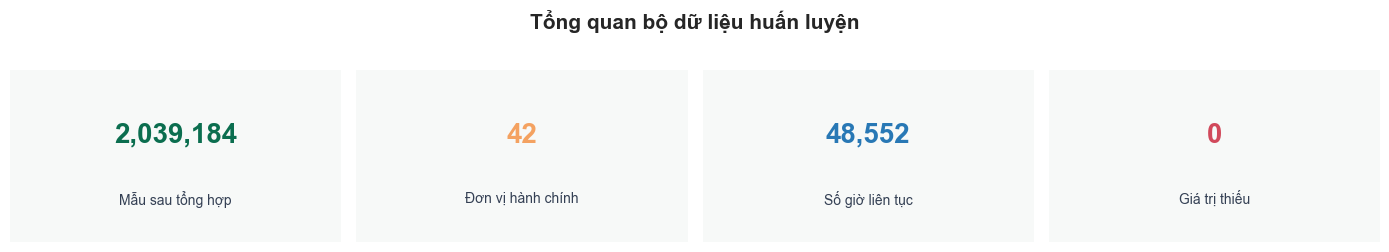

In [59]:
label_names = {
    'y_mua_lon': 'Mưa lớn',
    'y_sat_lo': 'Sạt lở',
    'y_dong_loc': 'Dông lốc',
    'y_mua_da': 'Mưa đá',
    'y_lu_lut': 'Lũ lụt',
}

kpis = [
    ('Mẫu sau tổng hợp', f'{len(df_model):,}'),
    ('Đơn vị hành chính', f'{df_model.location_id.nunique():,}'),
    ('Số giờ liên tục', f'{df_model.time.nunique():,}'),
    ('Giá trị thiếu', f'{int(df_model.isna().sum().sum()):,}'),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 2.4))
for ax, (title, value), color in zip(axes, kpis, COLORS):
    ax.set_facecolor('#F7F9F8')
    ax.text(.5, .62, value, ha='center', va='center', fontsize=20, fontweight='bold', color=color)
    ax.text(.5, .25, title, ha='center', va='center', fontsize=10, color='#344054')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
fig.suptitle('Tổng quan bộ dữ liệu huấn luyện', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

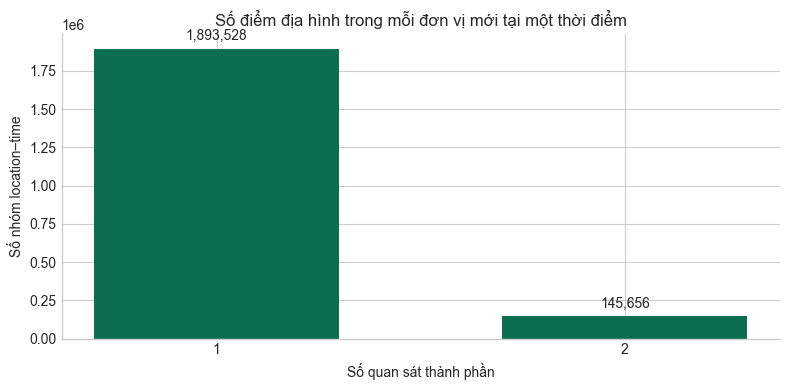

In [60]:
points_per_group = df.groupby(['location_id', 'time']).size()
point_distribution = points_per_group.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(point_distribution.index.astype(str), point_distribution.values, color=COLORS[0], width=.6)
ax.bar_label(bars, labels=[f'{v:,}' for v in point_distribution.values], padding=4, fontsize=10)
ax.set(title='Số điểm địa hình trong mỗi đơn vị mới tại một thời điểm', xlabel='Số quan sát thành phần', ylabel='Số nhóm location–time')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

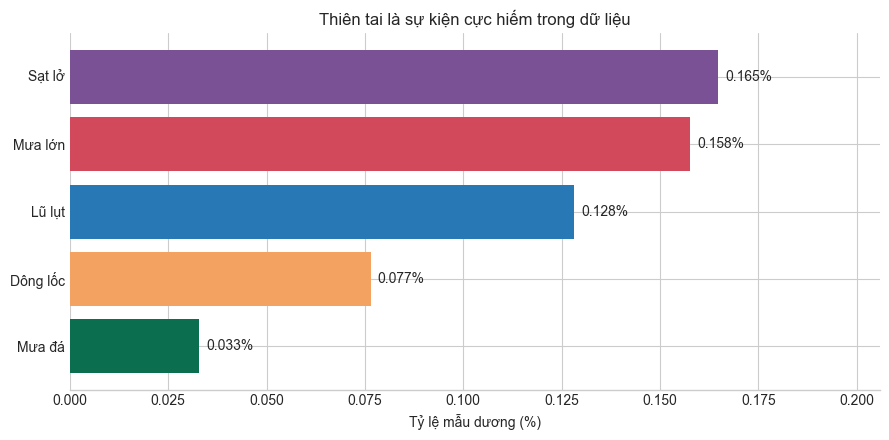

In [61]:
rates = df_model[TARGET_COLUMNS].mean().mul(100).rename(index=label_names).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(rates.index, rates.values, color=COLORS)
ax.bar_label(bars, labels=[f'{v:.3f}%' for v in rates.values], padding=5, fontsize=10)
ax.set(title='Thiên tai là sự kiện cực hiếm trong dữ liệu', xlabel='Tỷ lệ mẫu dương (%)', ylabel='')
ax.set_xlim(0, rates.max() * 1.25)
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.show()

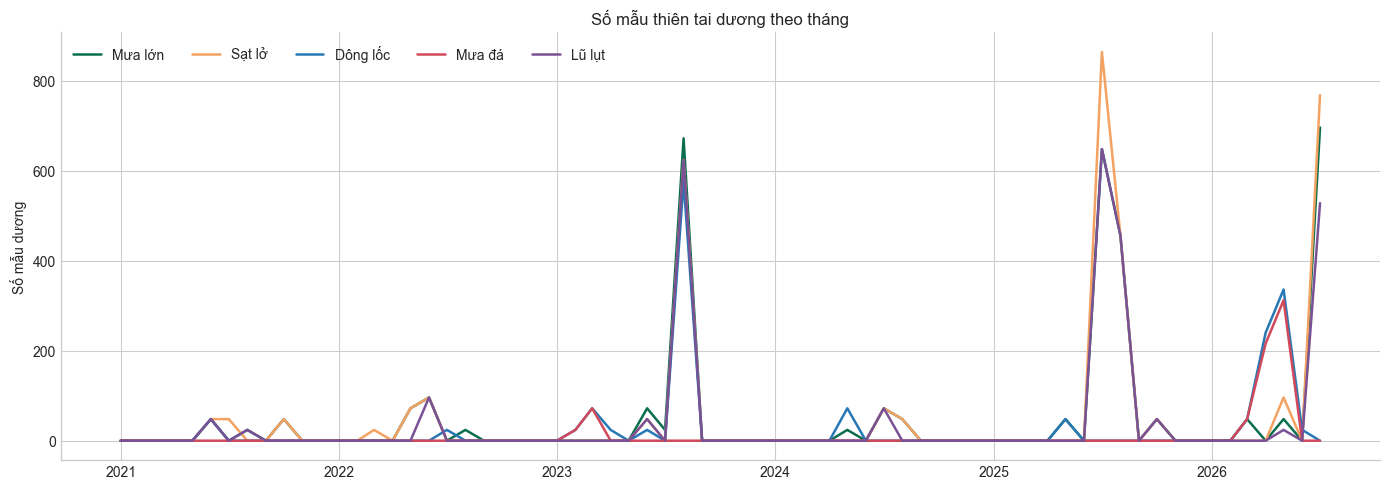

In [62]:
events_by_month = (
    df_model.set_index('time')[TARGET_COLUMNS]
            .resample('MS').sum()
            .rename(columns=label_names)
)

fig, ax = plt.subplots(figsize=(14, 5))
for column, color in zip(events_by_month.columns, COLORS):
    ax.plot(events_by_month.index, events_by_month[column], label=column, color=color, linewidth=1.8)
ax.set(title='Số mẫu thiên tai dương theo tháng', xlabel='', ylabel='Số mẫu dương')
ax.legend(ncol=5, loc='upper left', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

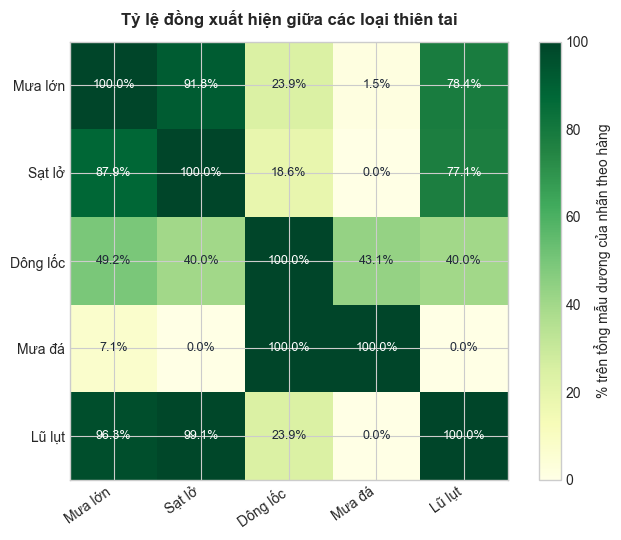

In [63]:
cooccurrence_pct = cooccurrence.div(np.diag(cooccurrence), axis=0).mul(100)
display_names = [label_names[c] for c in TARGET_COLUMNS]

fig, ax = plt.subplots(figsize=(7, 5.5))
image = ax.imshow(cooccurrence_pct, cmap='YlGn', vmin=0, vmax=100)
ax.set_xticks(range(len(display_names)), display_names, rotation=35, ha='right')
ax.set_yticks(range(len(display_names)), display_names)
for i in range(len(display_names)):
    for j in range(len(display_names)):
        value = cooccurrence_pct.iloc[i, j]
        ax.text(j, i, f'{value:.1f}%', ha='center', va='center', color='white' if value > 55 else '#1F2937', fontsize=9)
ax.set_title('Tỷ lệ đồng xuất hiện giữa các loại thiên tai', fontweight='bold', pad=12)
fig.colorbar(image, ax=ax, label='% trên tổng mẫu dương của nhãn theo hàng')
plt.tight_layout()
plt.show()

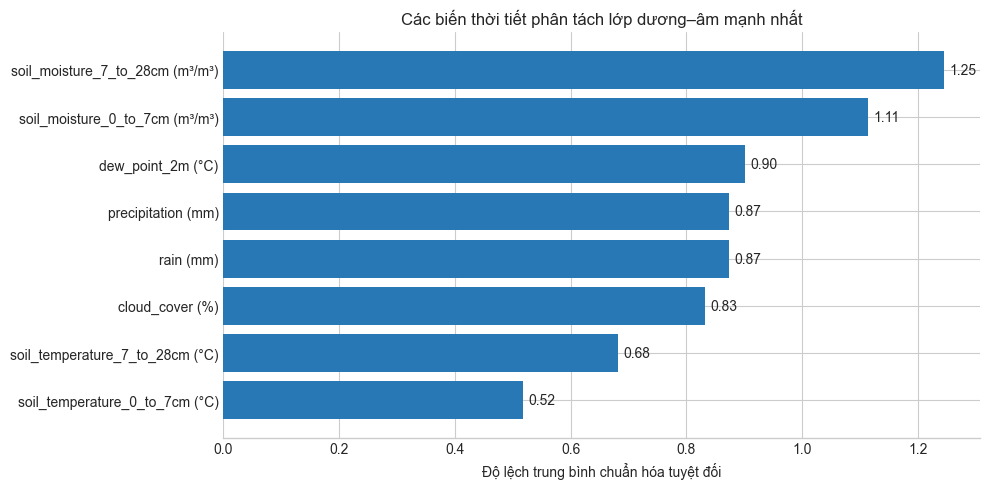

In [64]:
top_signal = (
    contrast.sort_values('standardized_mean_gap', ascending=False)
            .drop_duplicates('feature')
            .head(8)
            .sort_values('standardized_mean_gap')
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_signal['feature'], top_signal['standardized_mean_gap'], color=COLORS[2])
ax.bar_label(bars, fmt='%.2f', padding=4)
ax.set(title='Các biến thời tiết phân tách lớp dương–âm mạnh nhất', xlabel='Độ lệch trung bình chuẩn hóa tuyệt đối', ylabel='')
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Kết luận EDA và điều kiện trước khi train

1. **Quy mô nguồn:** 2.184.840 dòng × 22 cột, từ 2021-01-01 00:00 đến 2026-07-16 23:00; 48.552 mốc giờ và 42 `location_id` mới.
2. **Độ đầy đủ:** không có giá trị thiếu và không thiếu giờ trên trục thời gian chung.
3. **Nhiều quan sát có chủ đích:** có **145.656 nhóm `(location_id, time)` chứa nhiều dòng**, tập trung ở `location_id` 17, 25, 31. Đây là dữ liệu từ các đơn vị hành chính cũ có địa hình khác nhau được ánh xạ vào đơn vị mới, không phải nhiễu.
4. **Quy tắc chuẩn hóa đã chốt:** feature thời tiết lấy trung bình cộng theo `(location_id, time)`; nhãn `y_*` được gán 1 khi trung bình nhãn trong nhóm khác 0. Sau gộp còn 2.039.184 dòng duy nhất.
5. **Biến dư thừa:** `snow_depth` và `snowfall` là hằng số 0; `precipitation` và `rain` giống hoàn toàn. Nên loại các biến hằng và chỉ giữ một trong cặp trùng.
6. **Mất cân bằng cực mạnh:** tỷ lệ dương chỉ khoảng 0,033%–0,167%. Không dùng random split hoặc accuracy làm metric chính.
7. **Rủi ro nhãn:** cần xác minh 5 nhãn là sự kiện quan sát độc lập hay nhãn sinh bằng rule từ thời tiết cùng giờ. Với dự báo, target phải được dịch sang horizon tương lai (ví dụ 6h/24h), còn feature tại thời điểm `t` chỉ dùng dữ liệu `<= t`.

### Đề xuất cho Phần 2

- Chốt semantics của nhãn và horizon dự báo.
- Tạo lag/rolling theo từng địa điểm, luôn `shift(1)` trước rolling.
- Split train/validation/test theo thời gian; dành các khoảng sự kiện dương cho validation/test.
- Baseline: persistence/rule baseline trước, sau đó logistic regression hoặc gradient boosting có class weighting; đánh giá bằng PR-AUC và recall tại mức precision vận hành.